In [23]:
import pandas as pd

In [24]:
df = pd.read_csv("Argenprop_limpio.csv")

In [25]:
df

,Unnamed: 0,Precio,Expensas,Calle,Altura,Piso,Detalles,Descripción,Link,Ambientes,...,Hospital_cercano,Dist_Colegio_m,Colegios_500m,Dist_Comisaria_m,Dist_Gimnasio_m,Dist_Supermercado_m,Supermercados_500m,Dist_Avenida_m,Avenida_cercana,Paradas_colectivo_300m
0,1,150000.0,260000.000000,Bulnes,1600.0,No disponible,60 m² cubie. 2 dorm. 30 años,IMPECABLE! BALCÓN CORRIDO AL FRENTE CON VISTA ...,https://www.argenprop.com/departamento-en-vent...,3,...,Dr. J. A. Fernandez,180.353080,10,493.126679,51.727490,20.279331,10,156.788297,Avenida Santa Fe,19
1,2,330000.0,203300.000000,ARAOZ,1200.0,8,90 m² cubie. 3 dorm. A Estrenar,Venta 4 AMBIENTES con balcón Palermo + Cochera...,https://www.argenprop.com/departamento-en-vent...,4,...,R. Gutierrez,188.537726,11,403.114757,429.584392,249.248104,4,96.514964,Avenida Raúl Scalabrini Ortiz,10
2,3,270000.0,300000.000000,Honduras,3900.0,2,87 m² cubie. 2 dorm. 20 años,"Venta Semipiso 4 Ambientes, Dos Baños completo...",https://www.argenprop.com/departamento-en-vent...,4,...,Hospital Municipal de Oncologia M. Curie,240.873938,7,891.145341,383.017854,75.243729,7,425.495375,Avenida Coronel Niceto Vega,5
3,4,570000.0,1000000.000000,Castex,3300.0,No disponible,140 m² cubie. 3 dorm. 40 años,PALERMO CHICO espectacular piso alto con vista...,https://www.argenprop.com/departamento-en-vent...,4,...,Dr. J. A. Fernandez,256.797592,4,804.138281,286.697993,217.075594,3,108.444119,Avenida Casares,7
4,5,98000.0,150000.000000,GURRUCHAGA,2100.0,5,31 m² cubie. 15 años 1 baño,VENTA - DEPARTAMENTO 1 AMBIENTE AL FRENTE EN P...,https://www.argenprop.com/departamento-en-vent...,1,...,R. Gutierrez,153.610169,5,461.483469,393.568008,85.286744,6,378.802881,Avenida Raúl Scalabrini Ortiz,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7245,7986,55000.0,125000.000000,Olleros,1700.0,7,25 m² cubie. 1 baño Monoam.,Mono ambiente en excelente ubicación a 1 cuadr...,https://www.argenprop.com/departamento-en-vent...,1,...,Dr. E. Tornu,157.885597,13,881.495381,247.519742,169.405828,2,98.699159,Avenida Federico Lacroze,20
7246,7987,115000.0,100000.000000,Combate De Los Pozos,400.0,No disponible,65 m² cubie. 2 dorm. 2 baños,CARACTERÍSTICAS: -Superficie total: 81m2. -Sup...,https://www.argenprop.com/departamento-en-vent...,3,...,Gastroenterologia B. Udaondo,58.835455,10,399.896531,1260.991016,193.948438,1,62.511291,Avenida Entre Ríos,20
7247,7988,280000.0,320000.000000,Salguero,2500.0,No disponible,90 m² cubie. 3 dorm. 35 años,Departamento con inmejorable vista a la Plaza ...,https://www.argenprop.com/departamento-en-vent...,4,...,Dr. J. A. Fernandez,1077.852500,0,1140.555043,1088.028773,884.725141,0,103.688774,Avenida Costanera Rafael Obligado,2
7248,7989,105000.0,108429.553676,Segui,500.0,1,61 m² cubie. 2 dorm. 30 años,Excelente Departamento 3 Ambientes en Caballit...,https://www.argenprop.com/departamento-en-vent...,3,...,Hospital Especializado Oftalmologico Dr. P. La...,36.900981,11,1193.665366,431.930326,300.572295,2,364.827762,Avenida Warnes,5


Prueba K mean

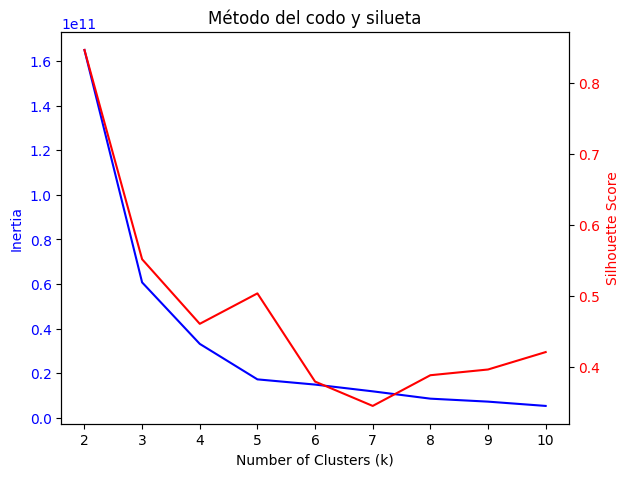

In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

barrio_features = df.groupby('Barrio').agg({
    'Precio': 'mean',
    'Expensas': 'mean',
    'Sup_Cubierta_m2': 'mean',
    'Sup_Total_m2': 'mean',
    'Ambientes': 'mean',
    'Dormitorios': 'mean',
    'Baños': 'mean',
    'Antiguedad': 'mean',}).dropna()

X = barrio_features.values

inertia = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

silhouette_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    silhouette_scores.append(silhouette_score(X, labels))

fig, ax1 = plt.subplots()

ax1.plot(k_range, inertia, 'b-', label='Inertia (Elbow)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax2 = ax1.twinx()
ax2.plot(k_range, silhouette_scores, 'r-', label='Silhouette Score')
ax2.set_ylabel('Silhouette Score', color='r')
ax2.tick_params(axis='y', labelcolor='r')
fig.tight_layout()
plt.title('Método del codo y silueta')
plt.show()

In [27]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X)
df['Cluster'] = df['Barrio'].map(dict(zip(barrio_features.index, barrio_features['Cluster'])))

KeyError: 'Cluster'

In [ ]:
df[df["Cluster"]==0]["Barrio"].unique()

array(['Saavedra', 'Colegiales', 'Parque Chacabuco', 'Caballito',
       'Villa Urquiza', 'Coghlan', 'Chacarita', 'Villa Ortuzar'],
      dtype=object)

In [ ]:
df[df["Cluster"]==1]["Barrio"].unique()

array(['Puerto Madero'], dtype=object)

In [ ]:
df[df["Cluster"]==2]["Barrio"].unique()

array(['Balvanera', 'Monserrat', 'San Cristobal', 'Villa Soldati',
       'Parque Patricios', 'Constitucion', 'Boedo', 'La Boca', 'Paternal',
       'Versalles', 'Velez Sarsfield', 'Nueva Pompeya', 'Villa Riachuelo'],
      dtype=object)

In [ ]:
df[df["Cluster"]==3]["Barrio"].unique()

array(['Palermo', 'Nuñez', 'Retiro', 'Recoleta', 'Belgrano'], dtype=object)

In [ ]:
df[df["Cluster"]==4]["Barrio"].unique()

array(['Flores', 'Almagro', 'Villa Crespo', 'Floresta', 'Agronomia',
       'San Nicolas', 'Villa Devoto', 'Liniers', 'Villa Pueyrredon',
       'Villa Real', 'Villa Del Parque', 'Barracas', 'Villa Gral. Mitre',
       'Parque Avellaneda', 'Parque Chas', 'Villa Santa Rita',
       'Monte Castro', 'Villa Lugano', 'Villa Luro', 'Mataderos',
       'San Telmo'], dtype=object)

In [ ]:
df.groupby("Cluster")[["Precio", "Expensas", "Sup_Cubierta_m2", "Sup_Total_m2", "Ambientes"]].mean()

,Precio,Expensas,Sup_Cubierta_m2,Sup_Total_m2,Ambientes
Cluster,,,,,
0,178640.241615,228908.541431,61.706939,70.178421,2.549624
1,502474.906667,582686.209625,101.538868,110.462907,2.706667
2,106405.310653,164779.729887,58.680154,64.240226,2.571134
3,219606.092299,295341.146351,73.697311,81.362970,2.771801
4,139690.794946,194785.835126,61.207604,69.214204,2.593261


Cluster 0:
* Estándar medio

Cluster 1:
* Premium amplio

Cluster 2:
* Económico chico

Cluster 3:
* Medio-Alto amplio

Cluster 4:
* Económico/Intermedio - compacto